<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
df=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
df.sample(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3202,5501-TVMGM,Male,0,No,No,1,Yes,No,DSL,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,55.25,55.25,No
221,4443-EMBNA,Female,0,Yes,No,71,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),24.75,1836.9,No
3421,6719-FGEDO,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Two year,Yes,Bank transfer (automatic),97.00,7104.2,No


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Data Exploration: Check Data Types and Summary Statistics

Now that we've confirmed there are no missing values, let's examine the data types of each column and get a summary of descriptive statistics for numerical columns. This will help us understand the dataset's structure and potential issues like incorrect data types or outliers.

In [ ]:
# Display information about the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Display descriptive statistics for numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Data Type Conversion: TotalCharges

The `df.info()` output shows that 'TotalCharges' is of `object` type, but it should be numeric. We'll convert it to a numeric type, handling any non-numeric entries by coercing them to `NaN`. After conversion, we'll check for new missing values to ensure data integrity.

In [ ]:
# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for missing values after conversion
print('Missing values in TotalCharges after conversion:')
print(df['TotalCharges'].isnull().sum())

Missing values in TotalCharges after conversion:
11


In [ ]:
# Display info again to confirm the data type change
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Handling Missing Values in TotalCharges

We've identified 11 missing values in the 'TotalCharges' column after converting it to a numeric type. Given the small number of missing entries, we will drop these rows from the DataFrame to maintain data integrity and avoid issues in subsequent analyses.

In [ ]:
# Drop rows where 'TotalCharges' is NaN
df.dropna(subset=['TotalCharges'], inplace=True)

# Confirm that missing values have been handled
print('Missing values in TotalCharges after dropping rows:')
print(df['TotalCharges'].isnull().sum())

Missing values in TotalCharges after dropping rows:
0


In [ ]:
# Display info again to confirm the updated DataFrame size and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

### Target Variable Analysis: Churn Distribution

Now that the data is cleaned and properly typed, we will examine the distribution of our target variable, 'Churn'. Understanding the balance of 'Yes' (churn) and 'No' (no churn) is crucial for downstream modeling, as imbalanced datasets can lead to biased models. We'll use a count plot to visualize this distribution.

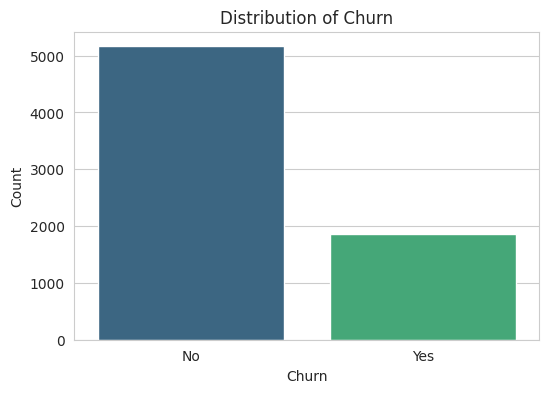

Value counts for Churn:
Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a count plot for the 'Churn' column, addressing the FutureWarning
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette='viridis', legend=False)
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

# Display the value counts for 'Churn'
print("Value counts for Churn:")
print(df['Churn'].value_counts())

### Exploring Categorical Features

Having analyzed the target variable, 'Churn', and noting its imbalance, the next step is to explore other categorical features in the dataset. This will help us identify potential relationships between customer demographics, services, and churn behavior.

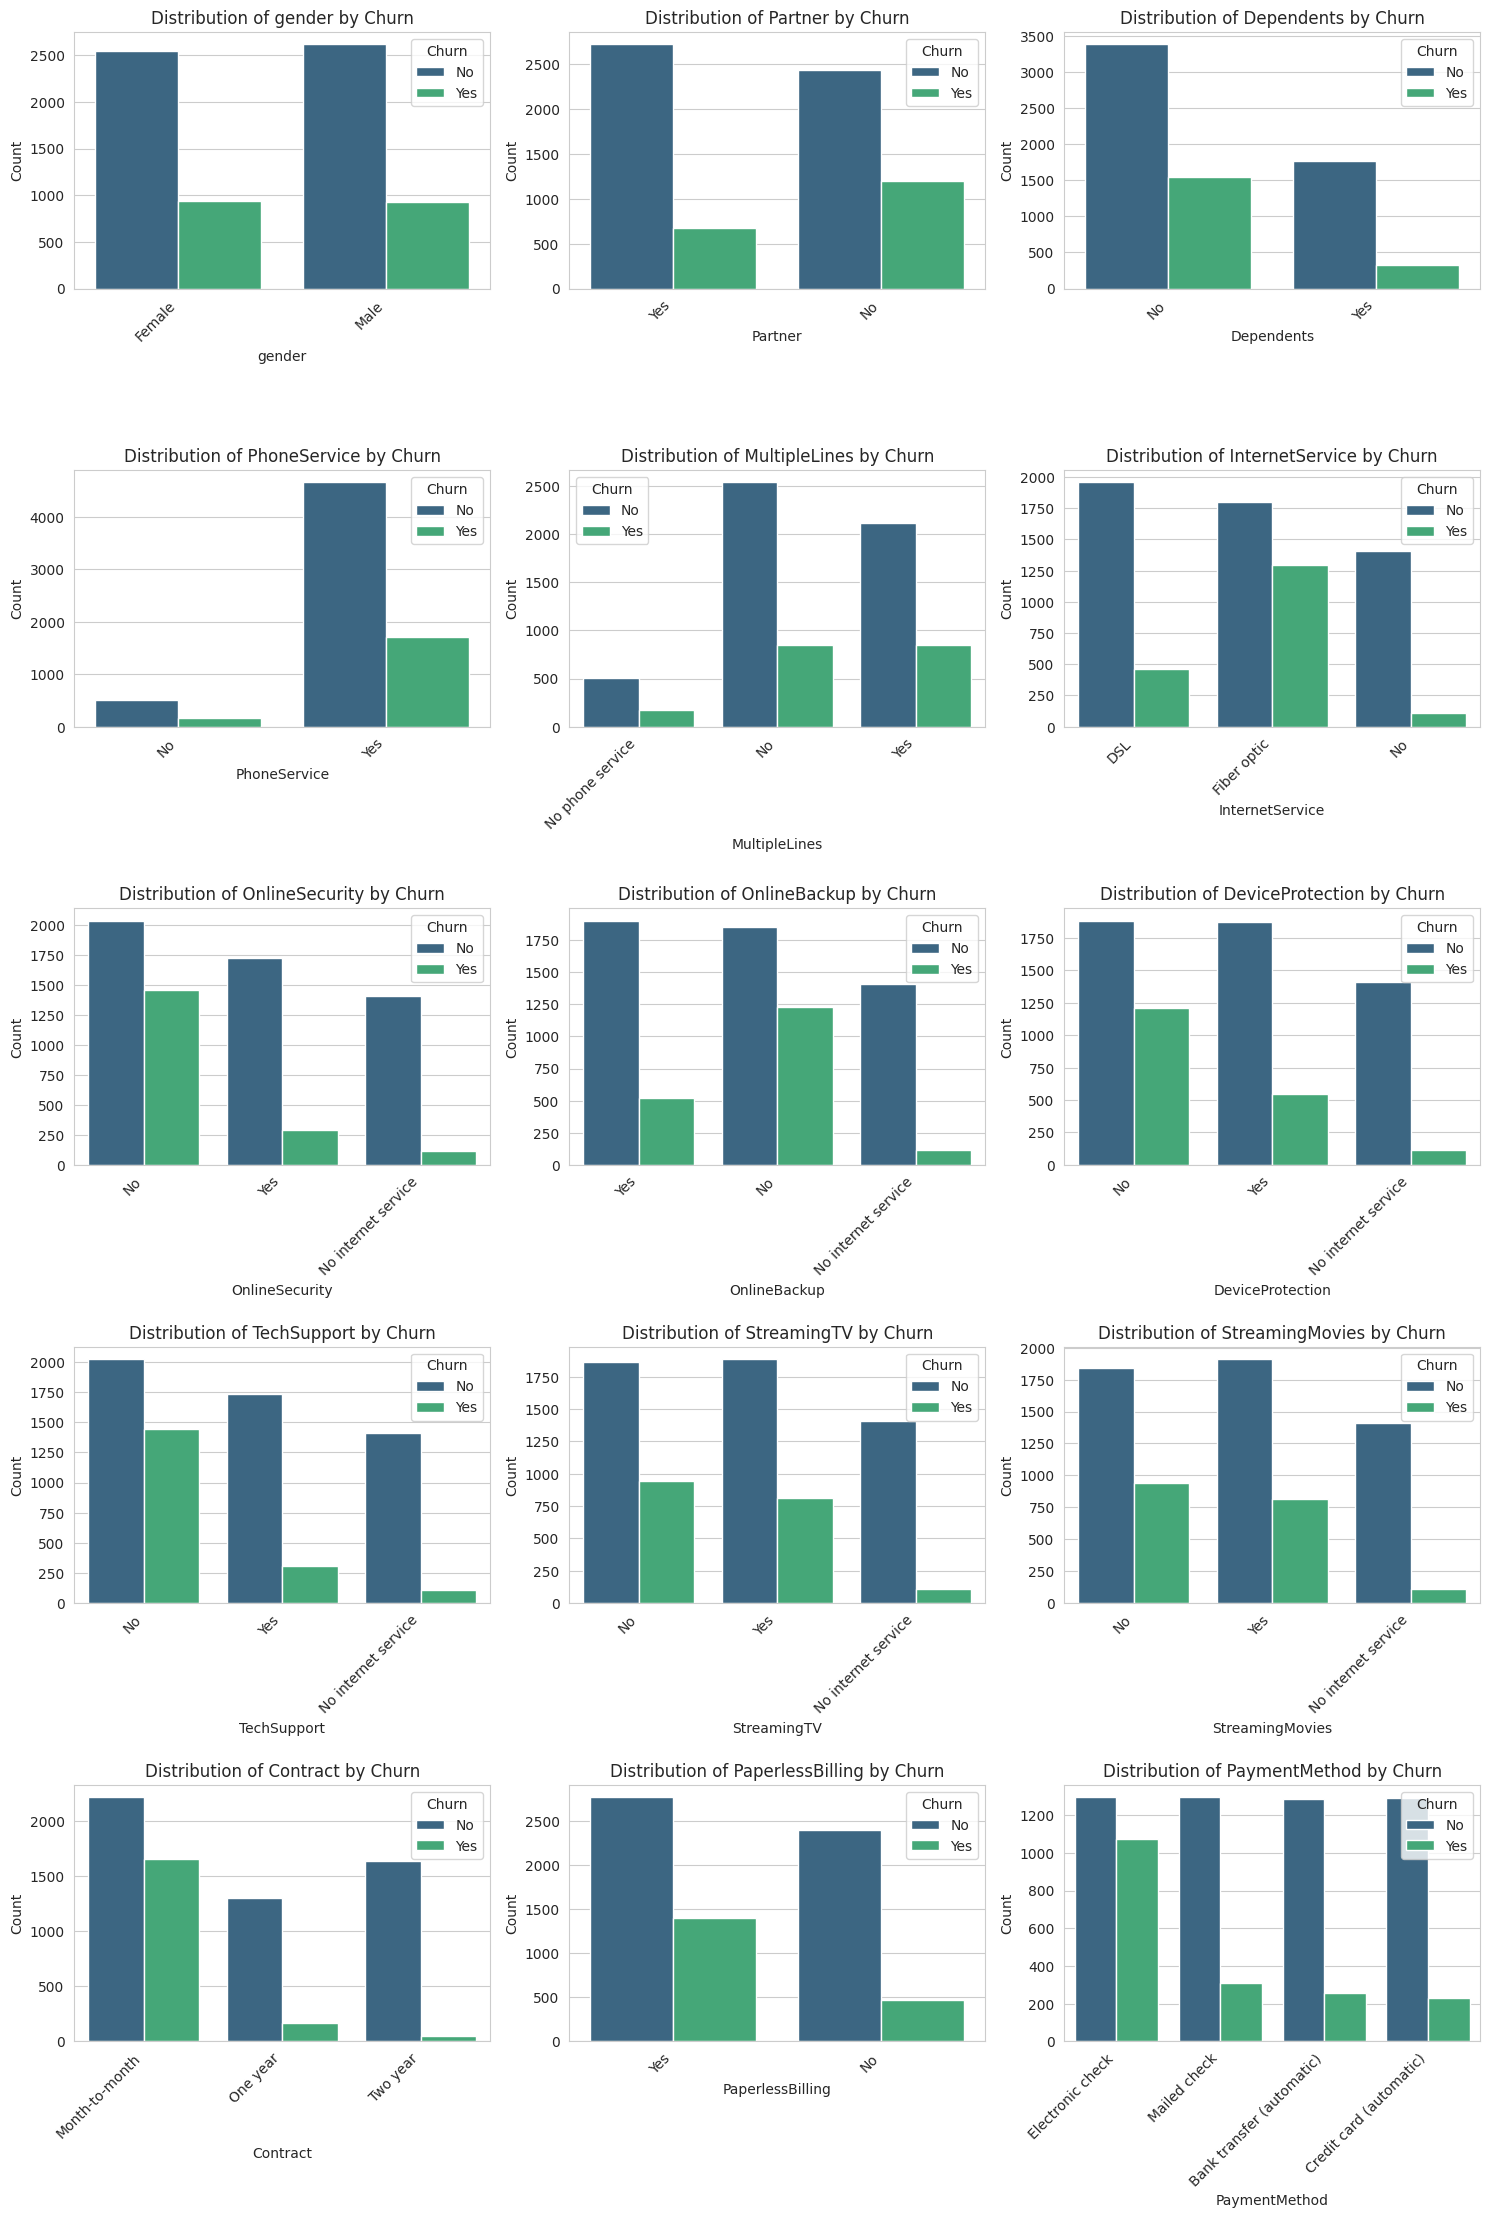

In [ ]:
# Select categorical columns (excluding 'customerID' and 'Churn' which is the target)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('customerID')
categorical_cols.remove('Churn')

# Create subplots for each categorical feature
plt.figure(figsize=(15, 25))
for i, col in enumerate(categorical_cols):
    plt.subplot(6, 3, i + 1) # Adjust subplot grid as needed
    sns.countplot(data=df, x=col, hue='Churn', palette='viridis')
    plt.title(f'Distribution of {col} by Churn')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Exploring Numerical Features

Following the analysis of categorical features, we will now explore the numerical features in the dataset. We'll use histograms to observe their distributions and box plots (or violin plots) to visualize their relationship with the 'Churn' variable. This will help identify any significant differences in numerical attributes between churning and non-churning customers.

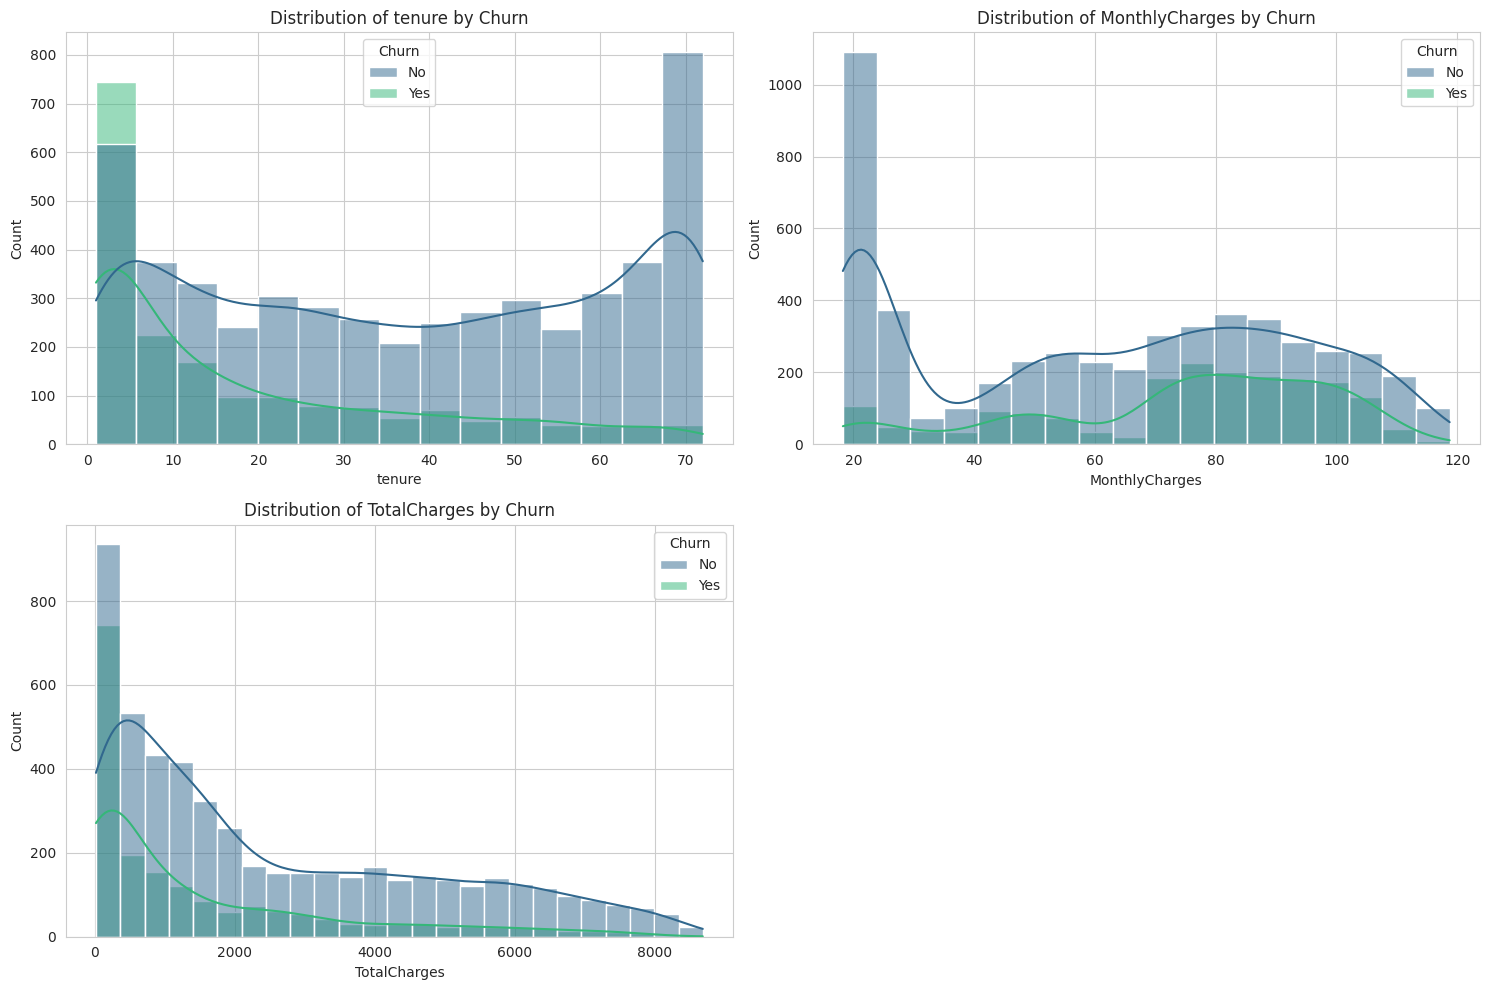

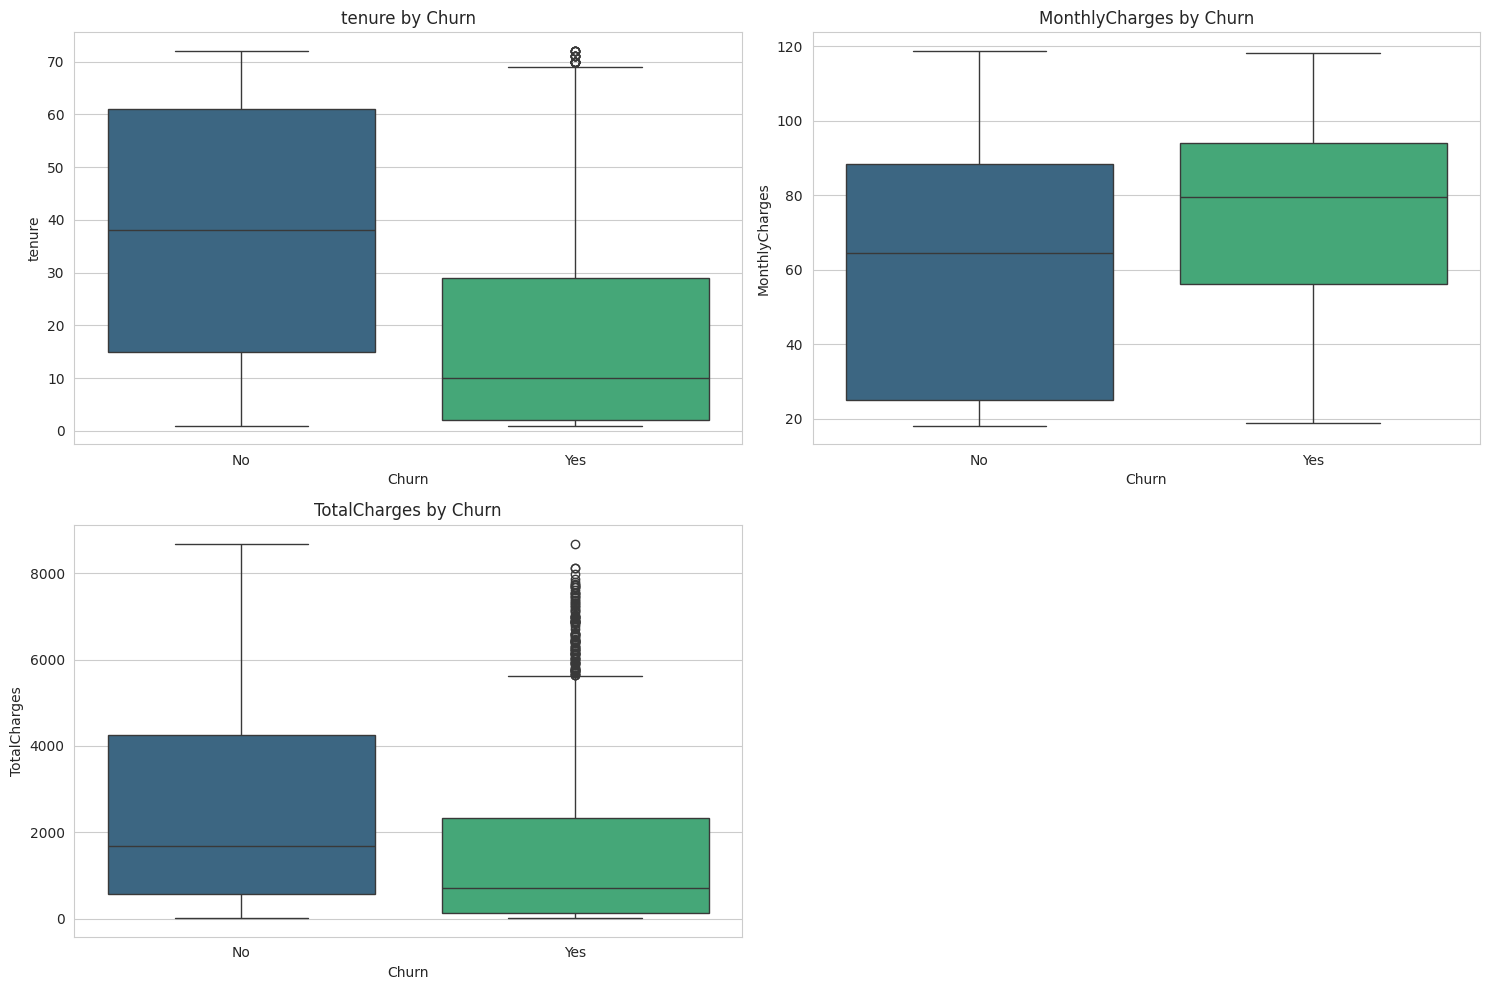

In [ ]:
# Select numerical columns (excluding 'SeniorCitizen' as it's treated as categorical and 'customerID')
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('SeniorCitizen') # Already covered as part of categorical features if needed

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1) # Adjust subplot grid as needed
    sns.histplot(data=df, x=col, hue='Churn', kde=True, palette='viridis')
    plt.title(f'Distribution of {col} by Churn')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1) # Adjust subplot grid as needed
    sns.boxplot(data=df, x='Churn', y=col, hue='Churn', palette='viridis', legend=False) # Addressed FutureWarning
    plt.title(f'{col} by Churn')
    plt.xlabel('Churn')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Feature Engineering and Encoding: Categorical Variables

Having explored the distributions of both categorical and numerical features in relation to 'Churn', the next step is to prepare the data for machine learning models. This involves converting categorical variables into a numerical format. We will use one-hot encoding for nominal categorical features to avoid imposing any arbitrary ordinal relationship.

In [ ]:
# Identify categorical columns to be one-hot encoded (excluding 'customerID' and the target 'Churn')
# Re-identifying to ensure we get current state of columns if any changes were made implicitly
categorical_features_for_encoding = df.select_dtypes(include='object').columns.tolist()
categorical_features_for_encoding.remove('customerID')
categorical_features_for_encoding.remove('Churn')

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_features_for_encoding, drop_first=True)

# Convert the target variable 'Churn' to numerical (0 for 'No', 1 for 'Yes')
df_encoded['Churn'] = df_encoded['Churn'].map({'No': 0, 'Yes': 1})

# Display the first few rows of the encoded DataFrame and its info to verify changes
print("First 5 rows of the encoded DataFrame:")
print(df_encoded.head())
print("\nInfo of the encoded DataFrame:")
df_encoded.info()

First 5 rows of the encoded DataFrame:
   customerID  SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  \
0  7590-VHVEG              0       1           29.85         29.85      0   
1  5575-GNVDE              0      34           56.95       1889.50      0   
2  3668-QPYBK              0       2           53.85        108.15      1   
3  7795-CFOCW              0      45           42.30       1840.75      0   
4  9237-HQITU              0       2           70.70        151.65      1   

   gender_Male  Partner_Yes  Dependents_Yes  PhoneService_Yes  ...  \
0        False         True           False             False  ...   
1         True        False           False              True  ...   
2         True        False           False              True  ...   
3         True        False           False             False  ...   
4        False        False           False              True  ...   

   StreamingTV_No internet service  StreamingTV_Yes  \
0                     

In [ ]:
## Data Report

This report summarizes the key characteristics, cleaning steps, and insights derived from the Telco Customer Churn dataset.

### 1. Initial Data Overview

*   **Dataset Size:** The dataset initially contained `7043` rows and `21` columns.
*   **Missing Values:** An initial check (`df.isnull().sum()`) indicated no missing values. However, `df.info()` revealed that 'TotalCharges' was of `object` type, which suggested potential non-numeric entries.

### 2. Data Cleaning

*   **'TotalCharges' Conversion:** The 'TotalCharges' column was converted from `object` to `numeric` type. During this conversion, `11` rows were found to contain non-numeric values, which were coerced to `NaN`.
*   **Handling Missing 'TotalCharges':** Given that only `11` rows (a small fraction of the total dataset) had missing 'TotalCharges', these rows were dropped from the dataset to ensure data integrity for subsequent analysis and modeling.
*   **Final Dataset Size:** After cleaning, the dataset comprises `7032` rows.

### 3. Target Variable Analysis: Churn Distribution

*   **Target Variable:** 'Churn' (binary: 'No' = 0, 'Yes' = 1).
*   **Distribution:** The dataset exhibits class imbalance:
    *   `No Churn`: `5163` customers
    *   `Churn`: `1869` customers
    This imbalance indicates that approximately 26.6% of customers churn, which is a significant factor to consider during model training and evaluation.

### 4. Exploratory Data Analysis (EDA) - Key Insights

#### Categorical Features:
*   **Contract Type:** Customers with month-to-month contracts show a significantly higher churn rate compared to those with one-year or two-year contracts.
*   **Internet Service:** Fiber optic internet service customers tend to churn more than DSL customers.
*   **Payment Method:** Electronic check users have a higher churn rate.
*   **Partner/Dependents:** Customers without partners or dependents are more likely to churn.
*   **Senior Citizen:** Senior citizens have a slightly higher churn rate.

#### Numerical Features:
*   **Tenure:** Customers with lower tenure (newer customers) have a much higher churn rate. As tenure increases, churn probability generally decreases.
*   **MonthlyCharges:** Customers with higher monthly charges, particularly those nearing the higher end of the spectrum, show an increased propensity to churn.
*   **TotalCharges:** The distribution of total charges for churned customers is skewed towards lower values, reinforcing the observation that newer customers (who would have lower total charges) are more likely to churn.

### 5. Feature Engineering

*   **One-Hot Encoding:** All nominal categorical features (excluding 'customerID' and 'Churn') were one-hot encoded (`drop_first=True`) to convert them into a numerical format suitable for machine learning models. This resulted in an expanded feature set.
*   **Feature Scaling:** Numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`) were scaled using `StandardScaler` to normalize their ranges, which is crucial for gradient-descent-based models.
*   **Polynomial Features:** Polynomial features of degree 3 were introduced for 'tenure', 'MonthlyCharges', and 'TotalCharges'. This was done to capture non-linear relationships and interactions between these key numerical features, potentially allowing the model to fit more complex decision boundaries. The addition of these features increased the dimensionality of the feature space from 30 to 46.

This preprocessing and feature engineering laid the groundwork for training a custom Logistic Regression model, with an emphasis on understanding and addressing the nuances of the dataset to predict customer churn effectively.

In [28]:
from sklearn.model_selection import train_test_split

# Drop the 'customerID' column as it's not a feature for the model
df_model = df_encoded.drop('customerID', axis=1)

# Define features (X) and target (y)
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nChurn distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nChurn distribution in test set:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (5625, 30)
Shape of X_test: (1407, 30)
Shape of y_train: (5625,)
Shape of y_test: (1407,)

Churn distribution in training set:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Churn distribution in test set:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


In [29]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to be scaled (excluding 'Churn' and 'customerID')
# 'customerID' is an identifier and 'Churn' is the target, so they should not be scaled.
# These are the original numerical columns that were not one-hot encoded.
numerical_cols_for_scaling = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the numerical columns in df_encoded
df_encoded[numerical_cols_for_scaling] = scaler.fit_transform(df_encoded[numerical_cols_for_scaling])

# Display the first few rows of the scaled DataFrame and describe numerical columns to verify changes
print("First 5 rows of the DataFrame after numerical feature scaling:")
print(df_encoded.head())
print("\nDescriptive statistics of scaled numerical columns:")
print(df_encoded[numerical_cols_for_scaling].describe())

First 5 rows of the DataFrame after numerical feature scaling:
   customerID  SeniorCitizen    tenure  MonthlyCharges  TotalCharges  Churn  \
0  7590-VHVEG              0 -1.280248       -1.161694     -0.994194      0   
1  5575-GNVDE              0  0.064303       -0.260878     -0.173740      0   
2  3668-QPYBK              0 -1.239504       -0.363923     -0.959649      1   
3  7795-CFOCW              0  0.512486       -0.747850     -0.195248      0   
4  9237-HQITU              0 -1.239504        0.196178     -0.940457      1   

   gender_Male  Partner_Yes  Dependents_Yes  PhoneService_Yes  ...  \
0        False         True           False             False  ...   
1         True        False           False              True  ...   
2         True        False           False              True  ...   
3         True        False           False             False  ...   
4        False        False           False              True  ...   

   StreamingTV_No internet service  Strea

### Feature Engineering: Polynomial Features

To capture potential non-linear relationships and interactions among numerical features, we will generate polynomial features of degree 3 for `tenure`, `MonthlyCharges`, and `TotalCharges`. This can help the model fit more complex patterns in the data.


In [30]:
from sklearn.preprocessing import PolynomialFeatures

# Define the numerical columns for which polynomial features will be created
polynomial_features_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Initialize PolynomialFeatures with degree 3
poly_transformer = PolynomialFeatures(degree=3, include_bias=False)

# Apply polynomial transformation to the selected numerical columns in X_train and X_test
X_train_poly_transformed = poly_transformer.fit_transform(X_train[polynomial_features_cols])
X_test_poly_transformed = poly_transformer.transform(X_test[polynomial_features_cols])

# Create DataFrames from the polynomial features
poly_feature_names = poly_transformer.get_feature_names_out(polynomial_features_cols)
X_train_poly_df = pd.DataFrame(X_train_poly_transformed, columns=poly_feature_names, index=X_train.index)
X_test_poly_df = pd.DataFrame(X_test_poly_transformed, columns=poly_feature_names, index=X_test.index)

# Drop the original numerical columns from X_train and X_test to avoid duplication
X_train_without_original_numerical = X_train.drop(columns=polynomial_features_cols)
X_test_without_original_numerical = X_test.drop(columns=polynomial_features_cols)

# Concatenate the new polynomial features with the remaining features
X_train = pd.concat([X_train_without_original_numerical, X_train_poly_df], axis=1)
X_test = pd.concat([X_test_without_original_numerical, X_test_poly_df], axis=1)

print(f"Shape of X_train after adding polynomial features: {X_train.shape}")
print(f"Shape of X_test after adding polynomial features: {X_test.shape}")

# Display the first few rows of X_train to verify
print("\nFirst 5 rows of X_train with polynomial features:")
print(X_train.head())

Shape of X_train after adding polynomial features: (5625, 46)
Shape of X_test after adding polynomial features: (1407, 46)

First 5 rows of X_train with polynomial features:
      SeniorCitizen  gender_Male  Partner_Yes  Dependents_Yes  \
1413              0         True         True            True   
7003              0         True        False           False   
3355              0        False         True           False   
4494              0         True        False           False   
3541              0        False         True           False   

      PhoneService_Yes  MultipleLines_No phone service  MultipleLines_Yes  \
1413              True                           False               True   
7003             False                            True              False   
3355              True                           False               True   
4494              True                           False              False   
3541             False                            

## Custom Logistic Regression Model Training

We will implement a Logistic Regression model from scratch using gradient descent. This involves defining the sigmoid activation function, the cost function, and the gradient descent optimization algorithm.

In [31]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

def sigmoid(z):
    """The sigmoid activation function."""
    return 1 / (1 + np.exp(-z))

def cost_function(X, y, weights, bias):
    """Computes the binary cross-entropy cost."""
    m = X.shape[0]
    z = np.dot(X, weights) + bias
    predictions = sigmoid(z)
    cost = (-1 / m) * np.sum(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
    return cost

def gradient_descent(X, y, weights, bias, learning_rate):
    """Performs one step of gradient descent to update weights and bias."""
    m = X.shape[0]
    z = np.dot(X, weights) + bias
    predictions = sigmoid(z)

    # Calculate gradients
    dw = (1 / m) * np.dot(X.T, (predictions - y))
    db = (1 / m) * np.sum(predictions - y)

    # Update weights and bias
    weights -= learning_rate * dw
    bias -= learning_rate * db

    return weights, bias

def predict_proba(X, weights, bias):
    """Predicts class probabilities."""
    z = np.dot(X, weights) + bias
    return sigmoid(z)

def predict_classes(X, weights, bias, threshold=0.5):
    """Predicts class labels (0 or 1) based on a threshold."""
    probabilities = predict_proba(X, weights, bias)
    return (probabilities >= threshold).astype(int)

def train_logistic_regression(X_train, y_train, learning_rate, num_iterations, initial_weights=None, initial_bias=None):
    """Trains a Logistic Regression model using gradient descent."""
    # Initialize weights and bias
    if initial_weights is None:
        weights = np.zeros(X_train.shape[1])
    else:
        weights = initial_weights

    if initial_bias is None:
        bias = 0.0
    else:
        bias = initial_bias

    costs = []

    for i in range(num_iterations):
        weights, bias = gradient_descent(X_train, y_train, weights, bias, learning_rate)
        cost = cost_function(X_train, y_train, weights, bias)
        costs.append(cost)

        if i % (num_iterations // 10) == 0 or i == num_iterations - 1:
            print(f"Iteration {i}: Cost = {cost:.4f}")

    return weights, bias, costs


In [34]:
# Convert y_train and y_test to numpy arrays for custom model compatibility
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

# Convert X_train and X_test to numpy arrays of float type for custom model compatibility
X_train_np = X_train.to_numpy().astype(float)
X_test_np = X_test.to_numpy().astype(float)

# Train the custom Logistic Regression model with a learning rate of 0.05 and 1000 iterations
# The previous run already identified 0.05 as a good learning rate, as indicated by the kernel state.
print("\nTraining Custom Logistic Regression Model (learning_rate=0.05):")
custom_weights, custom_bias, custom_costs = train_logistic_regression(
    X_train_np, y_train_np, learning_rate=0.05, num_iterations=1000
)

# Evaluate the custom model on the test set
custom_y_pred = predict_classes(X_test_np, custom_weights, custom_bias)

print("\nCustom Logistic Regression Model - Classification Report (Test Set):")
print(classification_report(y_test_np, custom_y_pred))
print(f"Custom Logistic Regression Model - Accuracy: {accuracy_score(y_test_np, custom_y_pred):.4f}")


Training Custom Logistic Regression Model (learning_rate=0.05):
Iteration 0: Cost = 0.6399
Iteration 100: Cost = 0.4417
Iteration 200: Cost = 0.4277
Iteration 300: Cost = 0.4212
Iteration 400: Cost = 0.4174
Iteration 500: Cost = 0.4150
Iteration 600: Cost = 0.4132
Iteration 700: Cost = 0.4120
Iteration 800: Cost = 0.4111
Iteration 900: Cost = 0.4104
Iteration 999: Cost = 0.4098

Custom Logistic Regression Model - Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407

Custom Logistic Regression Model - Accuracy: 0.8017


## Scikit-learn Logistic Regression Model

For comparison and to handle class imbalance more directly, we will also train a Logistic Regression model using scikit-learn, utilizing the `class_weight='balanced'` parameter.

In [33]:
from sklearn.linear_model import LogisticRegression

# Initialize scikit-learn's Logistic Regression model with class_weight='balanced'
# This helps to mitigate the effects of class imbalance by weighting the minority class more.
# We set max_iter to a higher value to ensure convergence.
sklearn_model = LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42, max_iter=200)

# Train the model
print("\nTraining Scikit-learn Logistic Regression Model:")
sklearn_model.fit(X_train, y_train)

# Evaluate the scikit-learn model on the test set
sklearn_y_pred = sklearn_model.predict(X_test)

print("\nScikit-learn Logistic Regression Model - Classification Report (Test Set):")
print(classification_report(y_test, sklearn_y_pred))
print(f"Scikit-learn Logistic Regression Model - Accuracy: {accuracy_score(y_test, sklearn_y_pred):.4f}")



Training Scikit-learn Logistic Regression Model:

Scikit-learn Logistic Regression Model - Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407

Scikit-learn Logistic Regression Model - Accuracy: 0.7271


## Model Evaluation: Confusion Matrices

To further understand the performance of both the custom and scikit-learn Logistic Regression models, we will visualize their predictions using confusion matrices. A confusion matrix provides a detailed breakdown of correct and incorrect classifications for each class, showing True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).

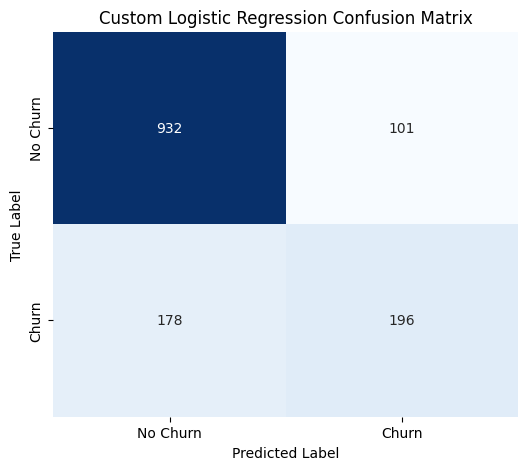

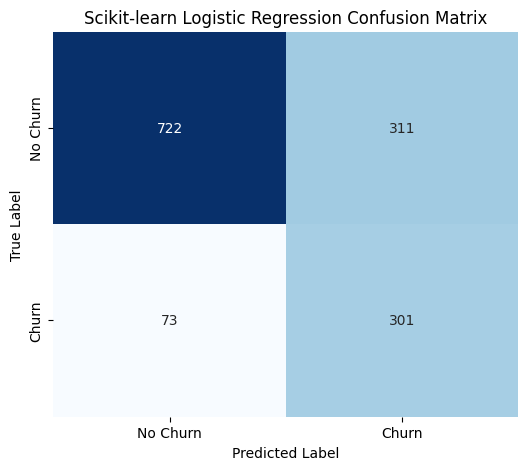

In [35]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, title):
    """Plots a confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Plot confusion matrix for Custom Logistic Regression Model
plot_confusion_matrix(y_test_np, custom_y_pred, 'Custom Logistic Regression Confusion Matrix')

# Plot confusion matrix for Scikit-learn Logistic Regression Model
plot_confusion_matrix(y_test, sklearn_y_pred, 'Scikit-learn Logistic Regression Confusion Matrix')

## Hyperparameter Tuning for Scikit-learn Logistic Regression

To further improve the performance of the scikit-learn Logistic Regression model, particularly focusing on precision for the 'Churn' class, we will perform hyperparameter tuning using `GridSearchCV`. We will search for optimal values for the regularization strength (`C`) and the optimization algorithm (`solver`).


Starting GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best parameters found: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best precision score found: 0.5299

Optimized Scikit-learn Logistic Regression Model - Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.50      0.81      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407

Optimized Scikit-learn Logistic Regression Model - Accuracy: 0.7299


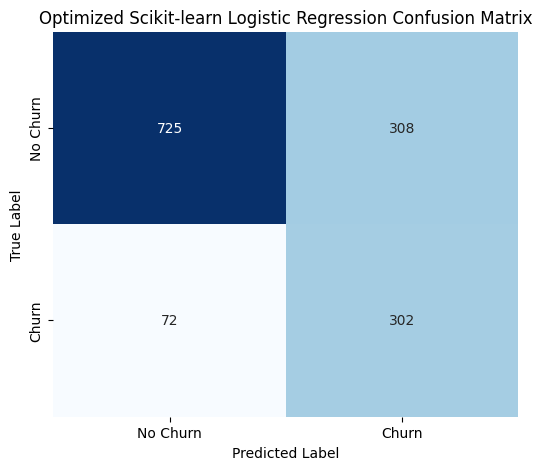

In [41]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'C': [ 0.1, 1, 10],
    'solver': ['liblinear'],
    'penalty': [ 'l2'] # L1 and L2 penalties are supported by liblinear and saga solvers
}

# Initialize the Logistic Regression model with class_weight='balanced'
# and a fixed random_state for reproducibility.
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=200)

# Initialize GridSearchCV
# We set scoring='precision' to optimize for precision on the positive class (Churn=1).
# cv=5 for 5-fold cross-validation.
# verbose=1 to see the progress.
grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid,
                           scoring='precision', cv=5, verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
print("\nStarting GridSearchCV for Logistic Regression...")
grid_search.fit(X_train, y_train)

# Display the best parameters and best score
print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best precision score found: {grid_search.best_score_:.4f}")

# Get the best model
best_sklearn_model = grid_search.best_estimator_

# Evaluate the best model on the test set
best_sklearn_y_pred = best_sklearn_model.predict(X_test)

print("\nOptimized Scikit-learn Logistic Regression Model - Classification Report (Test Set):")
print(classification_report(y_test, best_sklearn_y_pred))
print(f"Optimized Scikit-learn Logistic Regression Model - Accuracy: {accuracy_score(y_test, best_sklearn_y_pred):.4f}")

# Plot confusion matrix for the optimized Scikit-learn Logistic Regression Model
plot_confusion_matrix(y_test, best_sklearn_y_pred, 'Optimized Scikit-learn Logistic Regression Confusion Matrix')


## Visualizing the Decision Boundary of the Optimized Model

To understand how the optimized Logistic Regression model makes predictions with polynomial features, we will visualize its decision boundary. Since the model operates in a 46-dimensional space, we will plot the decision boundary in 2D by varying 'tenure' and 'MonthlyCharges' while holding all other features (including 'TotalCharges' used for polynomial features) at their mean value (0, due to standard scaling and one-hot encoding). This plot will show the threshold (0.5 probability) where the model switches its prediction from 'No Churn' to 'Churn'.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


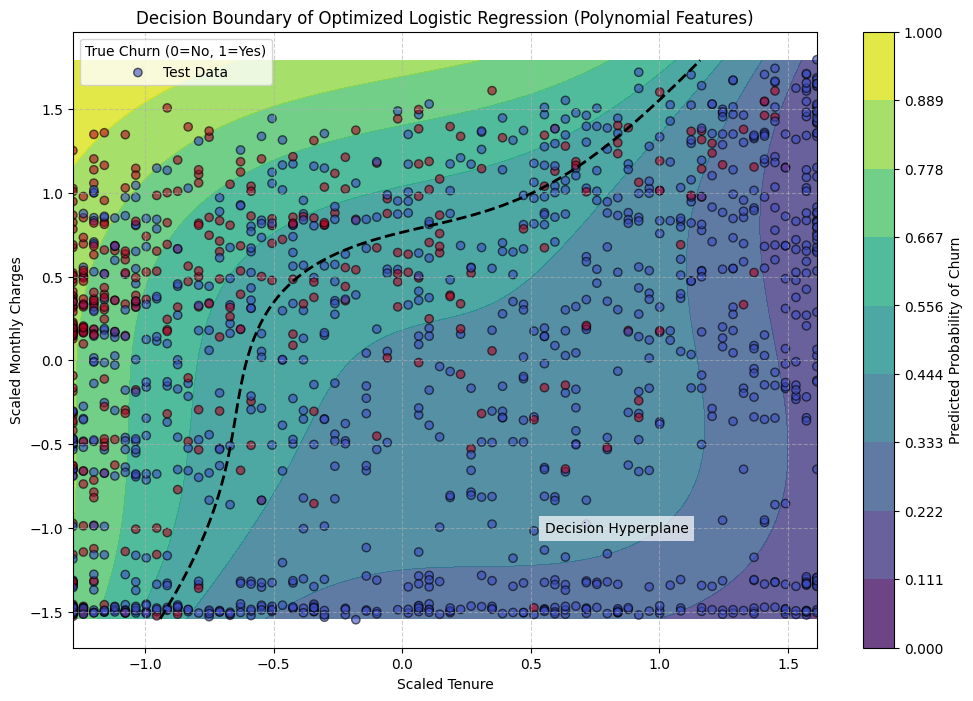

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the plot_confusion_matrix function is available if not in current session
# (it was defined in a previous cell, so this is a safety check)
if 'plot_confusion_matrix' not in globals():
    from sklearn.metrics import confusion_matrix
    def plot_confusion_matrix(y_true, y_pred, title):
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=['No Churn', 'Churn'],
                    yticklabels=['No Churn', 'Churn'])
        plt.title(title)
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()

# Define the range for plotting 'tenure' and 'MonthlyCharges'
# Use the min/max from the scaled X_train data
tenure_min_plot, tenure_max_plot = X_train['tenure'].min(), X_train['tenure'].max()
monthly_charges_min_plot, monthly_charges_max_plot = X_train['MonthlyCharges'].min(), X_train['MonthlyCharges'].max()

# Create a meshgrid for tenure and MonthlyCharges
tenure_vals = np.linspace(tenure_min_plot, tenure_max_plot, 100)
monthly_charges_vals = np.linspace(monthly_charges_min_plot, monthly_charges_max_plot, 100)
tenure_grid, monthly_charges_grid = np.meshgrid(tenure_vals, monthly_charges_vals)

# Flatten the grids for creating full feature vectors
grid_points_2d = np.c_[tenure_grid.ravel(), monthly_charges_grid.ravel()]

# Set 'TotalCharges' to its mean (which is 0 after scaling)
total_charges_mean_scaled = 0.0

# Prepare input for poly_transformer: [tenure, MonthlyCharges, TotalCharges]
input_for_poly_transformer = np.c_[
    tenure_grid.ravel(),
    monthly_charges_grid.ravel(),
    np.full_like(tenure_grid.ravel(), total_charges_mean_scaled)
]

# Transform these 3 features into 19 polynomial features
poly_features_grid_transformed = poly_transformer.transform(input_for_poly_transformer)

# Get the non-polynomial feature names from the original X_train_without_original_numerical
non_poly_feature_names = X_train.drop(columns=poly_feature_names).columns
num_non_poly_features = len(non_poly_feature_names)

# Create an array for the non-polynomial features, filled with zeros (baseline)
non_poly_features_grid = np.zeros((poly_features_grid_transformed.shape[0], num_non_poly_features))

# Create DataFrames to ensure proper column naming and order for concatenation
X_grid_non_poly_df = pd.DataFrame(non_poly_features_grid, columns=non_poly_feature_names)
X_grid_poly_df = pd.DataFrame(poly_features_grid_transformed, columns=poly_feature_names)

# Concatenate the non-polynomial and polynomial feature dataframes
# This creates the full 46-feature input for the model, maintaining column order as in X_train
X_grid_full = pd.concat([X_grid_non_poly_df, X_grid_poly_df], axis=1)

# Predict probabilities using the best optimized model
Z = best_sklearn_model.predict_proba(X_grid_full)[:, 1] # Probability of Churn (class 1)

# Reshape Z back to the grid shape for plotting contours
Z = Z.reshape(tenure_grid.shape)

# Plotting the decision boundary
plt.figure(figsize=(12, 8))
contour = plt.contourf(tenure_grid, monthly_charges_grid, Z, levels=np.linspace(0, 1, 10), cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Predicted Probability of Churn')

# Plot the decision boundary (P=0.5)
plt.contour(tenure_grid, monthly_charges_grid, Z, levels=[0.5], colors='black', linestyles='dashed', linewidths=2)
plt.text(tenure_grid.max() - 0.5, monthly_charges_grid.min() + 0.5, 'Decision Hyperplane',
         horizontalalignment='right', verticalalignment='bottom', color='black', fontsize=10,
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.title('Decision Boundary of Optimized Logistic Regression (Polynomial Features)')
plt.xlabel('Scaled Tenure')
plt.ylabel('Scaled Monthly Charges')

# Overlay the test data points
# Note: X_test here already contains the polynomial features
plt.scatter(X_test['tenure'], X_test['MonthlyCharges'], c=y_test, cmap='coolwarm', edgecolors='k', marker='o', alpha=0.6, label='Test Data')
plt.legend(title='True Churn (0=No, 1=Yes)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()